# The tSZ $Y$–$M$ relation & cluster mass bias under feedback

**Why it matters.** tSZ cluster cosmology (SPT, ACT, *Planck*, Simons
Observatory, CMB-S4) turns observed integrated Compton-$Y$ into halo masses
through the $Y$–$M$ scaling relation. Its **normalization, slope, and intrinsic
scatter** are set by baryonic feedback, and the dominant systematic is the mass
bias $(1-b)$: if $Y$–$M$ is calibrated on one feedback model but the real
Universe differs, inferred masses — and therefore $\sigma_8$/$\Omega_m$ from
cluster counts — are biased.

**The open question.** *How much does feedback move the $Y$–$M$ relation, and
what mass bias does that induce?* And: can BIND2 predict that bias?

**Why this tool.** The emulator produces $Y$ and $M_{200}$ for the *same* halo
across the 35-D SB35 feedback grid (and the clean 1P one-parameter sequences),
so we can fit $Y$–$M$ per feedback model, isolate which knobs move it, and
propagate the shift into a mass bias — all with a matched truth comparison.

**Rigor moves applied** (mirrored from the WL calibration notebook):
CV null floor (cosmic-variance and emulator scatter at fixed feedback) → bootstrap
68% CIs on every reported number → literature anchors (Arnaud+10 UPP,
Battaglia+12, Planck/WtG/CCCP mass-bias) → robustness sweep over the pivot mass
and the mass range → MLE `linmix_lite` fit that explicitly carries the intrinsic
scatter as a free parameter → scatter decomposition $\sigma^2_{\rm int} =
\sigma^2_{\rm CV} + \sigma^2_{\rm fb}$ → bootstrapped scorecard.

| § | Figure | Content |
|---|--------|---------|
| 1.5 | Y0 | **CV null floor**: per-halo $Y$–$M$ scatter and BIND emulator noise at fixed feedback |
| 2 | Y1 | $Y$–$M$ per suite — `linmix_lite` with literature slope anchors |
| 2.5 | Y1b | **Robustness**: pivot × mass-range sweep of slope/scatter (bootstrap CI heat-map) |
| 3 | Y2 | Feedback dependence of the $Y$–$M$ normalization (35-D, bootstrap CIs) |
| 4 | Y3 | Intrinsic $Y$–$M$ scatter vs feedback — CV floor & decomposition |
| 5 | Y4 | **Money plot — mass bias** from a mis-calibrated $Y$–$M$; literature $(1-b)$ band |
| 6 | Y5 | Clean 1P sequences with bootstrap envelopes |
| 7 | — | Bootstrapped scorecard |

$Y_{200}\equiv\sum y\,A_{\rm pix}$ within $R_{200}$ (extensive); masses are
$M_{200}$ from the DMO catalog.


## 0. Setup

In [ ]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, rankdata
from scipy.optimize import minimize

sys.path.insert(0, '/mnt/home/mlee1/vdm_bind2')
from metrics import CHANNEL_NAMES
from data import THERMO_KEYS, N_THERMO

plt.rcParams.update({
    'font.size': 10, 'font.family': 'serif', 'mathtext.fontset': 'cm',
    'figure.dpi': 120, 'savefig.dpi': 300, 'savefig.bbox': 'tight', 'axes.grid': False,
})
try:
    import scienceplots          # noqa: F401
    plt.style.use(['science', 'notebook'])
except Exception as exc:
    print(f'[scienceplots unavailable: {exc}]')

SUITE_ROOT = Path('/mnt/home/mlee1/ceph/fm_testsuite')
SNAP       = 'snap_090'
MASS_TAG   = 'mass_threshold_1p000e13'
MODEL_NAME = 'fm_thermo_ema'
BOX_SIZE   = 50.0
N_PIX_FULL = 1024
PATCH_PIX  = 128
PATCH_BOX  = BOX_SIZE * PATCH_PIX / N_PIX_FULL
PIX_MPC    = PATCH_BOX / PATCH_PIX
PIX_KPC    = PIX_MPC * 1000.0
PIX_AREA_MPC2 = PIX_MPC ** 2
N_PARAMS   = 35
M_PIVOT    = 14.0                                 # log10 M200 pivot for the Y-M fit
BOOT_N     = 500                                  # bootstrap resamples (raise for paper-grade)
RNG        = np.random.default_rng(20250528)

THERMO_SHORT = {'compton_y': 'Y', 'temperature': 'T', 'entropy': 'S', 'pressure': 'P'}

SUITES = ('CV', '1P', 'Test')
SUITE_COLORS  = {'CV': 'tab:green', '1P': 'tab:blue', 'Test': 'tab:red'}
SUITE_DISPLAY = {'CV': 'CV', '1P': '1P', 'Test': 'SB35'}

_param_meta = pd.read_csv(
    '/mnt/home/mlee1/Sims/IllustrisTNG_extras/L50n512/SB35/SB35_param_minmax.csv')
PARAM_NAMES = {i + 1: name for i, name in enumerate(_param_meta['ParamName'])}
PARAM_LABELS = {1: r'$\Omega_m$', 2: r'$\sigma_8$', 3: r'$A_{\rm SN1}$',
                4: r'$A_{\rm SN2}$', 5: r'$A_{\rm AGN1}$', 6: r'$A_{\rm AGN2}$'}
for _i in range(7, N_PARAMS + 1):
    PARAM_LABELS[_i] = PARAM_NAMES.get(_i, f'p{_i}')
FEEDBACK_PARAMS = [3, 4, 5, 6]                    # A_SN1, A_SN2, A_AGN1, A_AGN2

# ----------------------- Literature anchors -----------------------
# Y-M slope and intrinsic scatter at log M ~ 14:
#   self-similar:        slope = 5/3 = 1.667    (no feedback)
#   Arnaud+10 (UPP)      slope = 1.79  ± 0.08   sigma_int ~ 0.10 dex
#   Battaglia+12 (sims)  slope = 1.72  ± 0.04   sigma_int ~ 0.09 dex
#   Planck 2013 XX       slope = 1.79  ± 0.08   sigma_int ~ 0.10 dex
# Cluster-mass bias (1-b), Planck cosmology vs lensing-anchored:
#   Planck SZ counts     (1-b) = 0.58 ± 0.04    (cosmology preferred)
#   WtG (von der Linden) (1-b) = 0.69 ± 0.07
#   CCCP (Hoekstra+15)   (1-b) = 0.76 ± 0.05
YM_LIT = {
    'self-similar': {'slope': 5/3, 'sigma_int': 0.0, 'kind': 'theory'},
    'Arnaud+10 (UPP)':    {'slope': 1.79, 'slope_err': 0.08, 'sigma_int': 0.10},
    'Battaglia+12 (sim)': {'slope': 1.72, 'slope_err': 0.04, 'sigma_int': 0.09},
    'Planck 2013 XX':     {'slope': 1.79, 'slope_err': 0.08, 'sigma_int': 0.10},
}
MASS_BIAS_LIT = {
    'Planck cosmology':         {'1-b': 0.58, 'err': 0.04},
    'WtG (vdL+14)':             {'1-b': 0.69, 'err': 0.07},
    'CCCP (Hoekstra+15)':       {'1-b': 0.76, 'err': 0.05},
}

FIG_DIR = Path('tsz_ym_mass_bias_figs')
FIG_DIR.mkdir(exist_ok=True)


def save_fig(fig, name, ext=('pdf', 'png')):
    for e in ext:
        out = FIG_DIR / f'{name}.{e}'
        fig.savefig(out)
        print(f'  wrote {out}')


# ----------------------- statistical rigor helpers -----------------------
def bootstrap_ci(values, stat=np.nanmedian, n_boot=BOOT_N, ci=(16, 84), rng=RNG):
    """Bootstrap CI of `stat(values)`. Returns (point, lo, hi)."""
    v = np.asarray(values, float)
    v = v[np.isfinite(v)]
    if v.size < 3:
        return float('nan'), float('nan'), float('nan')
    idx = rng.integers(0, v.size, size=(n_boot, v.size))
    samples = np.array([stat(v[i]) for i in idx])
    lo, hi = np.nanpercentile(samples, ci)
    return float(stat(v)), float(lo), float(hi)


def bootstrap_curve(curves, stat=np.nanmedian, n_boot=BOOT_N, ci=(16, 84), rng=RNG):
    """Bootstrap CI of a curve aggregator over rows. curves: (N_obj, N_k)."""
    a = np.asarray(curves, float)
    if a.size == 0:
        return None
    idx = rng.integers(0, a.shape[0], size=(n_boot, a.shape[0]))
    boot = np.stack([stat(a[i], axis=0) for i in idx])
    return {'point': stat(a, axis=0),
            'lo': np.nanpercentile(boot, ci[0], axis=0),
            'hi': np.nanpercentile(boot, ci[1], axis=0)}


def spearman_boot(x, y, n_boot=BOOT_N, rng=RNG):
    x, y = np.asarray(x, float), np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y)
    x, y = x[m], y[m]
    if x.size < 10:
        return float('nan'), float('nan'), float('nan')
    rho = spearmanr(x, y).correlation
    idx = rng.integers(0, x.size, size=(n_boot, x.size))
    rb = np.array([spearmanr(x[i], y[i]).correlation for i in idx])
    return float(rho), float(np.nanpercentile(rb, 16)), float(np.nanpercentile(rb, 84))


def partial_spearman(x, y, z):
    m = np.isfinite(x) & np.isfinite(y) & np.isfinite(z)
    if m.sum() < 10:
        return float('nan')
    rx, ry, rz = rankdata(x[m]), rankdata(y[m]), rankdata(z[m])
    ax = rx - np.polyval(np.polyfit(rz, rx, 1), rz)
    ay = ry - np.polyval(np.polyfit(rz, ry, 1), rz)
    return float(spearmanr(ax, ay).correlation)


def partial_spearman_boot(x, y, z, n_boot=BOOT_N, rng=RNG):
    x, y, z = (np.asarray(v, float) for v in (x, y, z))
    m = np.isfinite(x) & np.isfinite(y) & np.isfinite(z)
    x, y, z = x[m], y[m], z[m]
    if x.size < 10:
        return float('nan'), float('nan'), float('nan')
    point = partial_spearman(x, y, z)
    idx = rng.integers(0, x.size, size=(n_boot, x.size))
    rb = np.array([partial_spearman(x[i], y[i], z[i]) for i in idx])
    return float(point), float(np.nanpercentile(rb, 16)), float(np.nanpercentile(rb, 84))


def fmt_ci(point, lo, hi, fmt='.3f'):
    return f'{point:{fmt}} [{lo:{fmt}}, {hi:{fmt}}]'


def linmix_lite(x, y, sigma_y=None, n_boot=BOOT_N, rng=RNG):
    """MLE for y = a*x + b with intrinsic scatter sigma_int.
    Returns slope, intercept, sigma_int with bootstrap 68% CIs."""
    x, y = np.asarray(x, float), np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y)
    x, y = x[m], y[m]
    if sigma_y is None:
        sy = np.zeros_like(y)
    else:
        sy = np.asarray(sigma_y, float)[m]
        sy = np.where(np.isfinite(sy), sy, 0.0)
    if x.size < 5:
        return {k: float('nan') for k in
                ('slope', 'intercept', 'sigma_int', 'n',
                 'slope_lo', 'slope_hi', 'intercept_lo', 'intercept_hi',
                 'sigma_int_lo', 'sigma_int_hi')}

    def nll(theta, xx, yy, ss):
        a, b, log_s = theta
        s2 = np.exp(2 * log_s) + ss ** 2
        r = yy - (a * xx + b)
        return 0.5 * np.sum(np.log(2 * np.pi * s2) + r ** 2 / s2)

    def fit(xx, yy, ss):
        a0, b0 = np.polyfit(xx, yy, 1)
        s0 = float(np.std(yy - (a0 * xx + b0))) + 1e-6
        res = minimize(nll, [a0, b0, np.log(s0)], args=(xx, yy, ss),
                       method='Nelder-Mead', options={'xatol': 1e-5, 'fatol': 1e-7})
        a, b, ls = res.x
        return a, b, float(np.exp(ls))

    a, b, sint = fit(x, y, sy)
    boots = []
    idx_all = rng.integers(0, x.size, size=(n_boot, x.size))
    for ii in idx_all:
        try:
            boots.append(fit(x[ii], y[ii], sy[ii]))
        except Exception:
            boots.append((np.nan, np.nan, np.nan))
    boots = np.array(boots)
    pct = lambda v, q: float(np.nanpercentile(v, q))
    return {'slope': float(a), 'intercept': float(b),
            'sigma_int': float(sint), 'n': int(x.size),
            'slope_lo': pct(boots[:, 0], 16), 'slope_hi': pct(boots[:, 0], 84),
            'intercept_lo': pct(boots[:, 1], 16), 'intercept_hi': pct(boots[:, 1], 84),
            'sigma_int_lo': pct(boots[:, 2], 16), 'sigma_int_hi': pct(boots[:, 2], 84)}


def decompose_scatter(sigma_total, sigma_floor):
    """Quadrature decomposition: feedback-driven scatter above the CV floor."""
    st, sf = float(sigma_total), float(sigma_floor)
    if not np.isfinite(st) or not np.isfinite(sf):
        return float('nan'), float('nan')
    diff2 = st ** 2 - sf ** 2
    return float(np.sqrt(max(diff2, 0.0))), float((sf / st) ** 2 if st > 0 else np.nan)


print('Fig dir:', FIG_DIR.resolve(), '| Y-M pivot logM =', M_PIVOT, f' | BOOT_N={BOOT_N}')


Fig dir: /mnt/home/mlee1/vdm_bind2/tsz_ym_mass_bias_figs | Y-M pivot logM = 14.0


## 1. Loaders & the per-halo $Y$–$M$ table

Light table (no full-box products): per halo, $\log M_{200}$, $R_{200}$, the
R200-aperture $Y_{200}$ and $T_{200}$ (truth and BIND), and the 35 params. Built
across CV, 1P, and SB35.

In [2]:
def sim_record(sim_dir, suite_name):
    snap, mass = sim_dir / SNAP, sim_dir / SNAP / MASS_TAG
    model = mass / MODEL_NAME
    rec = {'suite': suite_name, 'sim_id': sim_dir.name,
           'halo_catalog': mass / 'halo_catalog.npz',
           'truth_thermo': mass / 'truth_thermo_patches.npz',
           'generated': model / 'generated_halos.npz',
           'full_maps': snap / 'full_maps.npz'}
    rec['available'] = all(rec[k].exists() for k in
                           ('halo_catalog', 'truth_thermo', 'generated', 'full_maps'))
    return rec


def discover_sims(suites=SUITES):
    recs = []
    for suite in suites:
        root = SUITE_ROOT / suite
        if not root.exists():
            print(f'[skip] {root} missing'); continue
        for sd in sorted(root.iterdir()):
            if sd.is_dir():
                recs.append(sim_record(sd, suite))
    return pd.DataFrame(recs)


def extract_patch(field_2d, cx, cy, size=PATCH_PIX):
    n = field_2d.shape[0]; half = size // 2
    ix = (cx - half + np.arange(size)) % n
    iy = (cy - half + np.arange(size)) % n
    return field_2d[np.ix_(ix, iy)]


def centers_to_pixels(centers_mpc):
    return (np.asarray(centers_mpc) * (N_PIX_FULL / BOX_SIZE)).astype(np.int64) % N_PIX_FULL


def load_catalog(rec):
    d = np.load(rec['halo_catalog'])
    return {'centers': d['centers'], 'masses': d['masses'], 'radii': d['radii'],
            'params': d['params'] if 'params' in d.files else None}


_yy, _xx = np.mgrid[0:PATCH_PIX, 0:PATCH_PIX]
_RR = np.sqrt((_xx - PATCH_PIX / 2.0) ** 2 + (_yy - PATCH_PIX / 2.0) ** 2)


def build_ym_table(sims_df, verbose=True):
    rows = []
    for rec in sims_df.to_dict('records'):
        try:
            cat = load_catalog(rec)
            gen = np.load(rec['generated'])['generated']            # (N,7,H,W)
            tt = np.load(rec['truth_thermo'])['truth_thermo']       # (N,4,H,W)
            truth_maps = np.load(rec['full_maps'])['truth_maps']    # (3,H,W)
        except Exception as exc:
            if verbose:
                print(f'[skip] {rec["suite"]}/{rec["sim_id"]}: {exc}')
            continue
        cp = centers_to_pixels(cat['centers'])
        if len(cp) == 0:
            continue
        truth_gas = np.stack([extract_patch(truth_maps[1], cx, cy) for cx, cy in cp])
        masses, radii, params = cat['masses'], cat['radii'], cat['params']
        for i in range(len(masses)):
            ap = _RR <= max(radii[i] / PIX_KPC, 1.0)
            row = {'suite': rec['suite'], 'sim_id': rec['sim_id'],
                   'logM': float(np.log10(masses[i])), 'R200_kpc': float(radii[i])}
            # Y extensive; T gas-mass-weighted
            row['truth_Y'] = float(tt[i, 0][ap].sum()) * PIX_AREA_MPC2
            row['gen_Y']   = float(gen[i, 3][ap].sum()) * PIX_AREA_MPC2
            for which, Tmap, gas in (('truth', tt[i, 1], truth_gas[i]),
                                     ('gen',   gen[i, 4], gen[i, 1])):
                w = gas[ap]; sw = float(w.sum())
                row[f'{which}_T'] = float((Tmap[ap] * w).sum() / sw) if sw > 0 else np.nan
            if params is not None:
                pv = np.asarray(params[i], float)
                for j in range(N_PARAMS):
                    row[f'p{j + 1}'] = pv[j]
            rows.append(row)
    return pd.DataFrame(rows)


sims_all = discover_sims()
print(sims_all.groupby('suite')['available'].agg(['sum', 'count']))
sims = sims_all[sims_all['available']].reset_index(drop=True)
ym_tbl = build_ym_table(sims)
cv_tbl   = ym_tbl[ym_tbl['suite'] == 'CV']
oneP_tbl = ym_tbl[ym_tbl['suite'] == '1P']
sb_tbl   = ym_tbl[ym_tbl['suite'] == 'Test']
print(f'\nrows: CV={len(cv_tbl)} 1P={len(oneP_tbl)} SB35={len(sb_tbl)}')

       sum  count
suite            
1P     139    141
CV      27     27
Test   102    102
[skip] CV/sim_17: 'radii is not a file in the archive'

rows: CV=1111 1P=6823 SB35=4272


In [3]:
def fit_ym(logM, logY, pivot=M_PIVOT):
    # logY = slope*(logM - pivot) + norm; returns slope, norm, scatter(dex), n.
    m = np.isfinite(logM) & np.isfinite(logY)
    if m.sum() < 5:
        return np.nan, np.nan, np.nan, int(m.sum())
    x = logM[m] - pivot
    slope, norm = np.polyfit(x, logY[m], 1)
    scatter = float(np.std(logY[m] - (slope * x + norm)))
    return float(slope), float(norm), scatter, int(m.sum())


def _logY(tbl, which):
    v = tbl[f'{which}_Y'].to_numpy()
    with np.errstate(divide='ignore', invalid='ignore'):
        return np.where(v > 0, np.log10(v), np.nan)


# CV-calibrated Y-M (fiducial reference for the mass-bias analysis)
CV_FIT = {w: fit_ym(cv_tbl['logM'].to_numpy(), _logY(cv_tbl, w)) for w in ('truth', 'gen')}
print('CV Y-M fit (slope, norm@pivot, scatter, n):')
for w in ('truth', 'gen'):
    s, b, sc, n = CV_FIT[w]
    print(f'  {w:5s}: slope={s:.3f}  norm={b:.3f}  scatter={sc:.3f} dex  n={n}')

CV Y-M fit (slope, norm@pivot, scatter, n):
  truth: slope=1.935  norm=-5.643  scatter=0.190 dex  n=1111
  gen  : slope=1.885  norm=-5.634  scatter=0.208 dex  n=1111


## 1.5 Figure Y0 — CV null floor & emulator noise

Before measuring how feedback moves the $Y$–$M$ relation, we must know:

- $\sigma_{\rm CV}$ — the per-halo $Y$ scatter at **fixed feedback** (CV suite).
  This sets a floor on the $Y$–$M$ intrinsic scatter: nothing below this is
  feedback-driven, it is cosmic variance.
- $\sigma_{\rm emu}$ — the BIND-minus-truth per-halo $\log Y$ scatter on CV.
  This is the emulator noise at fixed feedback (an upper bound on what we can
  ever resolve about feedback shifts).

Any SB35 scatter that is larger than $\sigma_{\rm CV}$ in quadrature is the
genuine feedback signal; we will write it as $\sigma_{\rm fb} = \sqrt{\sigma_{\rm
int}^2 - \sigma_{\rm CV}^2}$ in §5 and the scorecard.


In [ ]:
def fig_y0_null_floor(save=True):
    """Per-halo Y residuals about the CV-truth Y-M fit (the CV scatter floor)
    and the BIND-truth per-halo Y residual on CV (emulator noise at fixed feedback)."""
    slope_cv, norm_cv, _, _ = CV_FIT['truth']
    lM = cv_tbl['logM'].to_numpy()
    lYt = _logY(cv_tbl, 'truth')
    lYg = _logY(cv_tbl, 'gen')
    resid_cv  = lYt - (slope_cv * (lM - M_PIVOT) + norm_cv)        # truth - fit  (CV floor)
    resid_emu = lYg - lYt                                          # BIND - truth (emulator noise)
    # SB35 residual about the CV-truth fit (what we will decompose later)
    lM_s = sb_tbl['logM'].to_numpy()
    lYt_s = _logY(sb_tbl, 'truth')
    resid_sb = lYt_s - (slope_cv * (lM_s - M_PIVOT) + norm_cv)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))

    ax = axes[0]
    bins = np.linspace(-0.5, 0.5, 50)
    ax.hist(resid_cv, bins=bins, color='0.5', alpha=0.6, label='CV (truth)')
    ax.hist(resid_sb, bins=bins, color='tab:red', alpha=0.55, label='SB35 (truth)')
    ax.axvline(0, color='k', lw=0.7, ls=':')
    s_cv, lo_cv, hi_cv = bootstrap_ci(resid_cv, np.nanstd)
    s_sb, lo_sb, hi_sb = bootstrap_ci(resid_sb, np.nanstd)
    ax.set_title(f'$\\log Y$ residual about CV $Y$–$M$ fit\n'
                 f'$\\sigma_{{CV}}$={fmt_ci(s_cv,lo_cv,hi_cv)} dex   '
                 f'$\\sigma_{{SB35}}$={fmt_ci(s_sb,lo_sb,hi_sb)} dex', fontsize=9)
    ax.set_xlabel(r'$\Delta\log Y$ [dex]'); ax.set_ylabel('# halos'); ax.legend(fontsize=8)

    ax = axes[1]
    bins = np.linspace(-0.5, 0.5, 60)
    ax.hist(resid_emu, bins=bins, color='tab:purple', alpha=0.6)
    ax.axvline(0, color='k', lw=0.7, ls=':')
    s_e, lo_e, hi_e = bootstrap_ci(resid_emu, np.nanstd)
    b_e, blo, bhi  = bootstrap_ci(resid_emu, np.nanmedian)
    ax.set_title(f'BIND − truth $\\log Y$  (CV halos)\n'
                 f'bias={fmt_ci(b_e,blo,bhi)}   $\\sigma_{{emu}}$={fmt_ci(s_e,lo_e,hi_e)} dex',
                 fontsize=9)
    ax.set_xlabel(r'$\log Y_{\rm BIND}-\log Y_{\rm truth}$ [dex]'); ax.set_ylabel('# halos')

    # CV truth Y-M with the fit overlaid (single panel showing why the residual is small)
    ax = axes[2]
    ax.scatter(lM, lYt, s=8, c='0.4', alpha=0.5, label='CV halos')
    xs = np.linspace(13, 15, 30)
    ax.plot(xs, slope_cv * (xs - M_PIVOT) + norm_cv, color='k', lw=2,
            label=f'CV fit: $\\alpha$={slope_cv:.2f} $\\sigma$={s_cv:.2f} dex')
    ax.axhspan(norm_cv - s_cv, norm_cv + s_cv, xmin=0, xmax=1,
               color='0.7', alpha=0.0)  # placeholder
    ax.set_xlabel(r'$\log_{10} M_{200}$'); ax.set_ylabel(r'$\log_{10} Y_{200}$')
    ax.set_title('CV calibration sample (used as null)'); ax.legend(fontsize=8)

    fig.tight_layout()
    if save:
        save_fig(fig, 'figY0_cv_null_floor')

    out = {'sigma_cv': s_cv, 'sigma_sb35': s_sb,
           'sigma_emu_cv': s_e, 'bias_emu_cv': b_e,
           'cv_slope': slope_cv, 'cv_norm': norm_cv}
    sigma_fb, frac = decompose_scatter(s_sb, s_cv)
    print(f'\nCV scatter floor (Y about M fit)        : sigma_CV  = {s_cv:.3f} dex')
    print(f'SB35 total scatter (truth, CV-anchored)   : sigma_SB  = {s_sb:.3f} dex')
    print(f'Feedback-driven Y-M scatter above floor   : sigma_fb  = {sigma_fb:.3f} dex')
    print(f'  ({100*(1-frac):.0f}% of SB35 variance is feedback, {100*frac:.0f}% is CV floor)')
    print(f'BIND emulator floor (CV)                  : sigma_emu = {s_e:.3f} dex, bias={b_e:+.3f}')
    return fig, out


fig, CV_NULL = fig_y0_null_floor()
plt.show()


## 2. Figure Y1 — The $Y$–$M$ relation per suite

The relation with its power-law fit per suite (truth vs BIND). Self-similar
expectation is $Y\propto M^{5/3}$ (slope 1.67); feedback flattens it at low mass
by ejecting gas. We report slope, normalization at the pivot, and intrinsic
scatter.

  wrote tsz_ym_mass_bias_figs/figY1_ym_relation.pdf
  wrote tsz_ym_mass_bias_figs/figY1_ym_relation.png


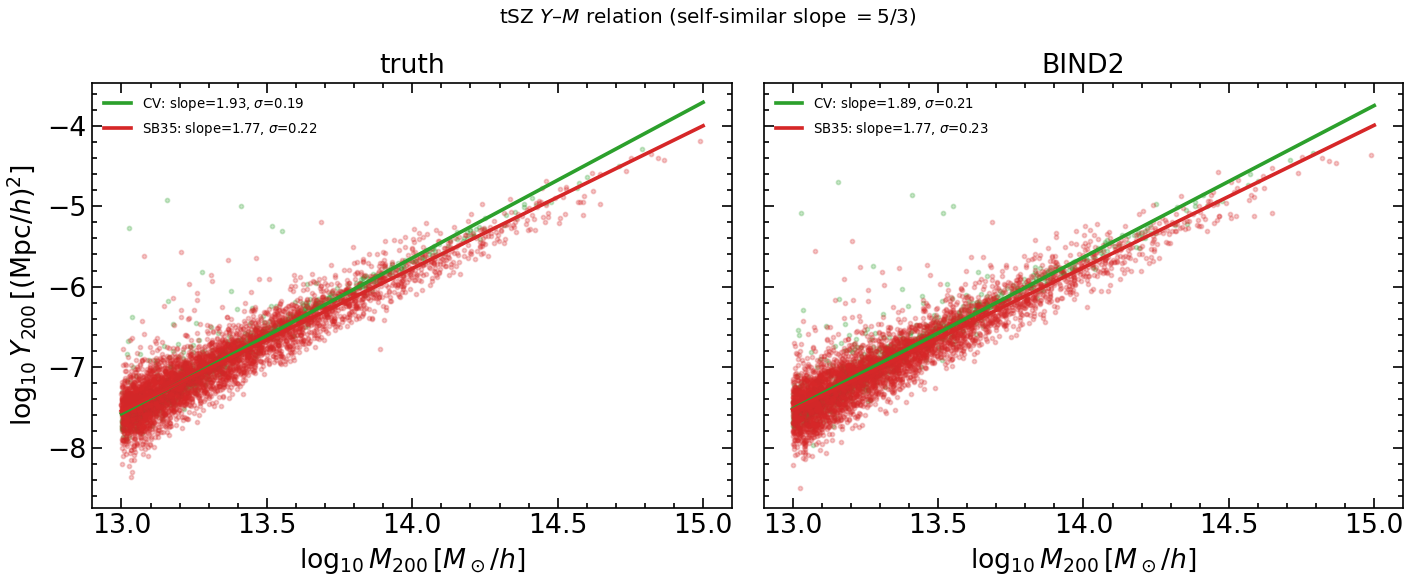

In [ ]:
def fig_y1_relation(save=True):
    """Y-M per suite with linmix_lite (slope, intercept, sigma_int + bootstrap CIs)
    and literature slope anchors overlaid."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
    fits = {}
    xs = np.linspace(13, 15, 60)
    for k, which in enumerate(['truth', 'gen']):
        ax = axes[k]
        for suite, sub in (('CV', cv_tbl), ('SB35', sb_tbl)):
            lM = sub['logM'].to_numpy(); lY = _logY(sub, which)
            col = SUITE_COLORS['CV'] if suite == 'CV' else SUITE_COLORS['Test']
            ax.scatter(lM, lY, s=6, c=col, alpha=0.25)
            f = linmix_lite(lM - M_PIVOT, lY)
            fits[(which, suite)] = f
            ys = f['slope'] * (xs - M_PIVOT) + f['intercept']
            ax.plot(xs, ys, color=col, lw=2.2,
                    label=(f'{suite}: $\\alpha$={f["slope"]:.2f}'
                           f'[{f["slope_lo"]:.2f},{f["slope_hi"]:.2f}]   '
                           f'$\\sigma_{{int}}$={f["sigma_int"]:.2f}'
                           f'[{f["sigma_int_lo"]:.2f},{f["sigma_int_hi"]:.2f}] dex  '
                           f'(n={f["n"]})'))
            ax.fill_between(xs, ys - f['sigma_int'], ys + f['sigma_int'],
                            color=col, alpha=0.10)

        # Literature slope anchors at the pivot — show as short line segments
        y_pivot = fits[(which, 'CV')]['intercept']
        for name, e in YM_LIT.items():
            ax.plot([M_PIVOT - 0.4, M_PIVOT + 0.4],
                    [y_pivot - 0.4 * e['slope'], y_pivot + 0.4 * e['slope']],
                    color='k', lw=1.0,
                    ls={'self-similar': ':', 'Arnaud+10 (UPP)': '--',
                        'Battaglia+12 (sim)': '-.', 'Planck 2013 XX': (0, (3, 1, 1, 1))}.get(name, '--'),
                    alpha=0.7)
        # legend with literature
        from matplotlib.lines import Line2D
        lit_handles = [Line2D([0], [0], color='k', lw=1,
                              ls={'self-similar': ':', 'Arnaud+10 (UPP)': '--',
                                  'Battaglia+12 (sim)': '-.', 'Planck 2013 XX': (0, (3, 1, 1, 1))}.get(name, '--'),
                              label=f'{name} ($\\alpha={e["slope"]:.2f}$)')
                       for name, e in YM_LIT.items()]
        l1 = ax.legend(loc='upper left', fontsize=7)
        ax.add_artist(l1)
        ax.legend(handles=lit_handles, loc='lower right', fontsize=6, title='lit. slopes at pivot')
        ax.set_xlabel(r'$\log_{10} M_{200}\,[M_\odot/h]$')
        ax.set_title('truth' if which == 'truth' else 'BIND2')

    axes[0].set_ylabel(r'$\log_{10} Y_{200}\,[(\mathrm{Mpc}/h)^2]$')
    fig.suptitle(r'tSZ $Y$–$M$ — `linmix_lite` MLE (slope, $\sigma_{\rm int}$, bootstrap 68% CI)',
                 y=0.98)
    fig.tight_layout()
    if save:
        save_fig(fig, 'figY1_ym_relation')

    print('=' * 64)
    for (w, s), f in fits.items():
        sig_cv = globals().get('CV_NULL', {}).get('sigma_cv', float('nan'))
        sig_fb, frac = decompose_scatter(f['sigma_int'], sig_cv)
        print(f'[{w:5s} / {s:4s}]  slope = {fmt_ci(f["slope"], f["slope_lo"], f["slope_hi"])}'
              f'   sigma_int = {fmt_ci(f["sigma_int"], f["sigma_int_lo"], f["sigma_int_hi"])} dex'
              f'   sigma_fb = {sig_fb:.3f} ({100*(1-frac):.0f}% of variance)')
    return fig, fits


fig, Y1_FITS = fig_y1_relation()
plt.show()


## 2.5 Figure Y1b — Robustness: does the slope survive analyst choices?

If the $Y$–$M$ slope, intercept, and intrinsic scatter depend on which mass
pivot you pick or which mass range you fit, the result is an analyst choice and
should not be quoted as a measurement. Here we sweep:

- **pivot mass** $\log M_{\rm pivot}\in\{13.5,\,14.0,\,14.5\}$ (the intercept moves
  along the relation; the slope and $\sigma_{\rm int}$ should not).
- **fit range** $\log M\in$ `[13, 15.5]`, `[13.3, 15.5]`, `[13.7, 15.5]` (low-mass
  truncation; the slope can flatten if the sample is mass-biased).

Each cell of the heat-map shows the bootstrap median + 68% CI of the relevant
quantity. Robust if all cells agree within their CIs.


In [ ]:
PIVOTS = [13.5, 14.0, 14.5]
MASS_RANGES = {'all (logM>=13)': (13.0, 15.5),
               'logM>=13.3':     (13.3, 15.5),
               'logM>=13.7':     (13.7, 15.5)}


def fig_y1b_robustness(tbl=None, save=True):
    if tbl is None:
        tbl = sb_tbl
    lM_all = tbl['logM'].to_numpy(); lY_all = _logY(tbl, 'truth')
    nP, nR = len(PIVOTS), len(MASS_RANGES)
    slope_g = np.full((nP, nR), np.nan); slope_lo = slope_g.copy(); slope_hi = slope_g.copy()
    sig_g   = np.full((nP, nR), np.nan); sig_lo   = sig_g.copy();   sig_hi   = sig_g.copy()
    n_g     = np.zeros((nP, nR), int)
    for ip, piv in enumerate(PIVOTS):
        for jr, (lab, (mlo, mhi)) in enumerate(MASS_RANGES.items()):
            sel = (lM_all >= mlo) & (lM_all <= mhi) & np.isfinite(lY_all)
            f = linmix_lite(lM_all[sel] - piv, lY_all[sel])
            slope_g[ip, jr] = f['slope']; slope_lo[ip, jr] = f['slope_lo']; slope_hi[ip, jr] = f['slope_hi']
            sig_g[ip, jr]   = f['sigma_int']; sig_lo[ip, jr]   = f['sigma_int_lo']; sig_hi[ip, jr]   = f['sigma_int_hi']
            n_g[ip, jr]     = f['n']

    fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))
    titles = (f'slope $\\alpha$ (SB35 truth)',
              f'intrinsic $\\sigma_{{int}}$ [dex] (SB35 truth)')
    for ax, grid, glo, ghi, vlim, cm, ttl in zip(
            axes, [slope_g, sig_g], [slope_lo, sig_lo], [slope_hi, sig_hi],
            [(1.4, 2.0), (0.0, 0.20)], ['viridis', 'magma'], titles):
        mappable = ax.imshow(grid, vmin=vlim[0], vmax=vlim[1], cmap=cm, aspect='auto')
        ax.set_xticks(range(nR)); ax.set_xticklabels(list(MASS_RANGES.keys()), rotation=20, ha='right')
        ax.set_yticks(range(nP)); ax.set_yticklabels([f'pivot={p}' for p in PIVOTS])
        for ip in range(nP):
            for jr in range(nR):
                ax.text(jr, ip, f'{grid[ip,jr]:.2f}\n[{glo[ip,jr]:.2f},{ghi[ip,jr]:.2f}]\nn={n_g[ip,jr]}',
                        ha='center', va='center', fontsize=7,
                        color='white' if grid[ip,jr] < (vlim[0]+vlim[1])/2 else 'k')
        fig.colorbar(mappable, ax=ax, fraction=0.04)
        ax.set_title(ttl)
    fig.suptitle('Robustness sweep: pivot × mass range  (bootstrap 68% CI in brackets)', y=1.02)
    fig.tight_layout()
    if save:
        save_fig(fig, 'figY1b_robustness_grid')

    print('pivot × mass-range slope sweep (SB35 truth):')
    for ip, p in enumerate(PIVOTS):
        line = ' | '.join(f'{lab}: a={slope_g[ip,jr]:+.2f}[{slope_lo[ip,jr]:+.2f},{slope_hi[ip,jr]:+.2f}]'
                          for jr, lab in enumerate(MASS_RANGES))
        print(f'  pivot={p}  {line}')
    return fig


fig = fig_y1b_robustness()
plt.show()


## 3. Figure Y2 — Feedback dependence of the $Y$–$M$ normalization

Per SB35 sim, fit the normalization at the pivot (fixed CV slope), giving the
$Y$–$M$ amplitude offset $\Delta\log Y$ for each feedback model. Spearman of that
offset against all 35 parameters reveals which knobs move the relation (expect
AGN/SN feedback). Truth vs BIND.

  wrote tsz_ym_mass_bias_figs/figY2_norm_response.pdf
  wrote tsz_ym_mass_bias_figs/figY2_norm_response.png


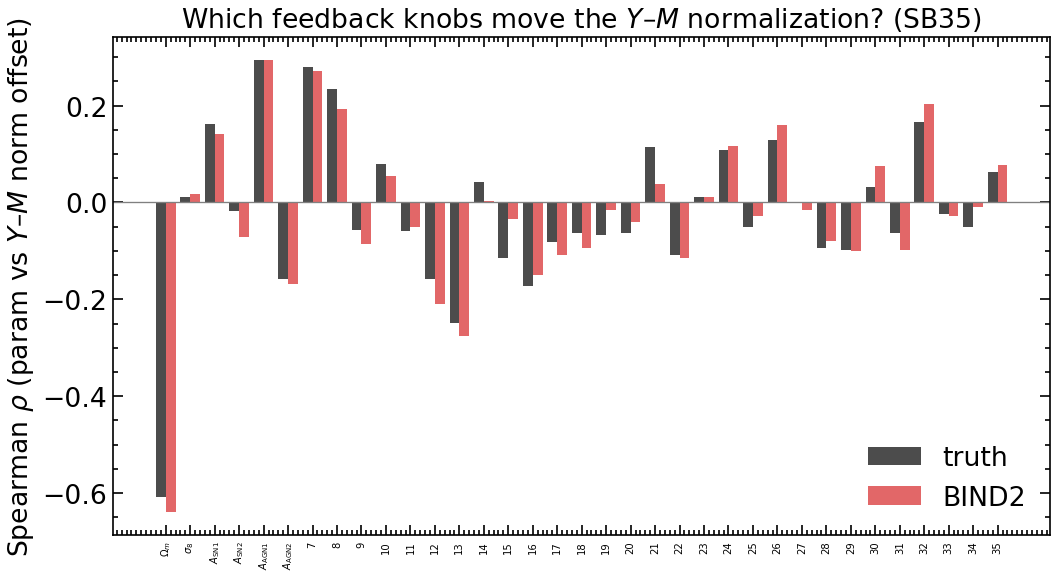

In [ ]:
def per_sim_ym_offsets(tbl, which, slope=None):
    """Per-sim Y-M normalization offset at pivot, using a fixed slope (CV truth)."""
    if slope is None:
        slope = CV_FIT['truth'][0]
    rows = []
    for sid, sub in tbl.groupby('sim_id'):
        lM = sub['logM'].to_numpy(); lY = _logY(sub, which)
        m = np.isfinite(lM) & np.isfinite(lY)
        if m.sum() < 5:
            continue
        resid = lY[m] - slope * (lM[m] - M_PIVOT)        # = norm + per-halo scatter
        row = {'sim_id': sid, 'norm': float(np.median(resid)),
               'scatter': float(np.std(resid)), 'n': int(m.sum())}
        for j in range(1, N_PARAMS + 1):
            row[f'p{j}'] = float(sub[f'p{j}'].iloc[0])
        rows.append(row)
    return pd.DataFrame(rows)


def fig_y2_norm_response(save=True):
    """35-D Spearman bar chart with bootstrap 68% CI error bars."""
    fig, ax = plt.subplots(figsize=(10, 5.2))
    width = 0.4
    rhos = {}
    for which in ('truth', 'gen'):
        off = per_sim_ym_offsets(sb_tbl, which)
        r_pt = np.full(N_PARAMS, np.nan)
        r_lo = np.full(N_PARAMS, np.nan); r_hi = np.full(N_PARAMS, np.nan)
        for j in range(1, N_PARAMS + 1):
            pv = off[f'p{j}'].to_numpy()
            if np.nanstd(pv) > 0:
                p, lo, hi = spearman_boot(pv, off['norm'].to_numpy())
                r_pt[j - 1], r_lo[j - 1], r_hi[j - 1] = p, lo, hi
        rhos[which] = (r_pt, r_lo, r_hi)
    x = np.arange(1, N_PARAMS + 1)
    for k, (which, col) in enumerate((('truth', 'k'), ('gen', 'tab:red'))):
        r_pt, r_lo, r_hi = rhos[which]
        off_x = -width / 2 if k == 0 else width / 2
        err = np.vstack([r_pt - r_lo, r_hi - r_pt])
        ax.bar(x + off_x, r_pt, width, color=col, alpha=0.7, label=which,
               yerr=err, capsize=2, error_kw={'elinewidth': 0.6})
    ax.axhline(0, color='0.5', lw=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels([PARAM_LABELS[j] if j <= 6 else str(j) for j in x],
                       rotation=90, fontsize=6)
    ax.set_ylabel(r'Spearman $\rho$ (param vs $Y$–$M$ norm offset, 68% bootstrap)')
    ax.set_title('Which feedback knobs move the $Y$–$M$ normalization? (SB35)')
    ax.legend()
    fig.tight_layout()
    if save:
        save_fig(fig, 'figY2_norm_response')
    # Top-4 drivers per which
    for w in ('truth', 'gen'):
        r_pt, r_lo, r_hi = rhos[w]
        order = np.argsort(-np.abs(r_pt))
        print(f'\n[{w}] top-4 norm drivers:')
        for k in order[:4]:
            j = k + 1
            print(f'   p{j:2d} {PARAM_LABELS[j]:14s} rho = {fmt_ci(r_pt[k], r_lo[k], r_hi[k], ".2f")}')
    return fig, rhos


fig, Y2_RHOS = fig_y2_norm_response()
plt.show()


## 4. Figure Y3 — Intrinsic $Y$–$M$ scatter vs feedback

Scatter in $Y$–$M$ directly inflates the mass-function selection and the cluster
cosmology error budget. Here: per-sim intrinsic scatter (about the fixed-slope
relation) vs the leading feedback parameters, truth vs BIND.

  wrote tsz_ym_mass_bias_figs/figY3_scatter_vs_feedback.pdf
  wrote tsz_ym_mass_bias_figs/figY3_scatter_vs_feedback.png


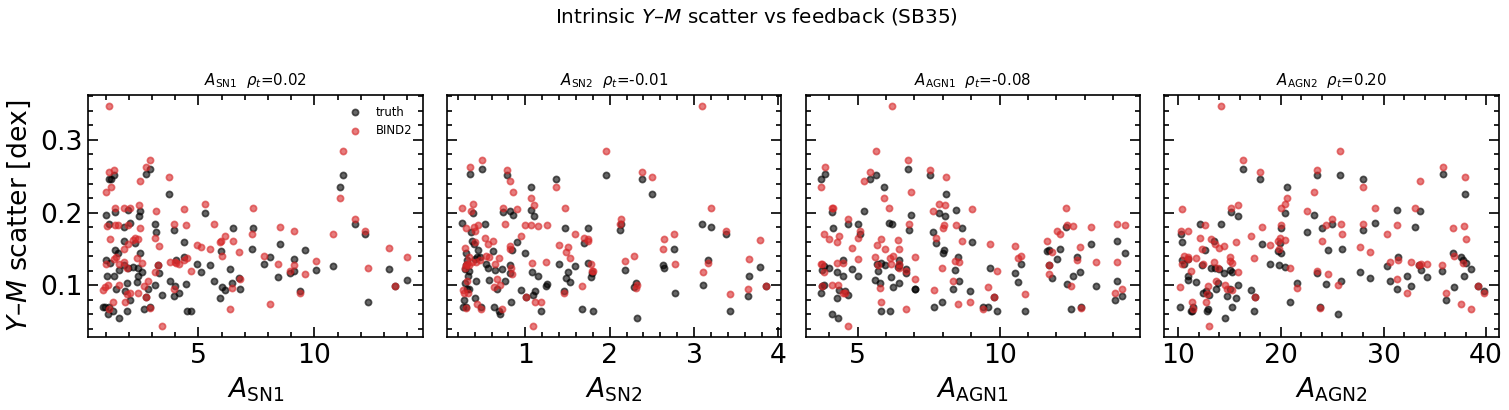

In [ ]:
def fig_y3_scatter(save=True):
    """Per-sim Y-M intrinsic scatter vs the four feedback knobs, truth vs BIND,
    with the CV scatter floor as a horizontal grey band and bootstrap CI on rho."""
    off_t = per_sim_ym_offsets(sb_tbl, 'truth')
    off_g = per_sim_ym_offsets(sb_tbl, 'gen')
    sig_cv = globals().get('CV_NULL', {}).get('sigma_cv', float('nan'))
    fig, axes = plt.subplots(1, len(FEEDBACK_PARAMS),
                             figsize=(3.4 * len(FEEDBACK_PARAMS), 3.6), sharey=True)
    for c, j in enumerate(FEEDBACK_PARAMS):
        ax = axes[c]
        if np.isfinite(sig_cv):
            ax.axhspan(0, sig_cv, color='0.85', alpha=0.6,
                       label=f'CV floor $\\sigma_{{CV}}$={sig_cv:.3f}' if c == 0 else None)
        ax.scatter(off_t[f'p{j}'], off_t['scatter'], s=18, c='k', alpha=0.7, label='truth' if c == 0 else None)
        ax.scatter(off_g[f'p{j}'], off_g['scatter'], s=18, c='tab:red', alpha=0.7, label='BIND2' if c == 0 else None)
        rt, lo, hi = spearman_boot(off_t[f'p{j}'].to_numpy(), off_t['scatter'].to_numpy())
        rg, lg, hg = spearman_boot(off_g[f'p{j}'].to_numpy(), off_g['scatter'].to_numpy())
        ax.set_title(f'{PARAM_LABELS[j]}\n$\\rho_t$={fmt_ci(rt, lo, hi, ".2f")}\n$\\rho_g$={fmt_ci(rg, lg, hg, ".2f")}',
                     fontsize=8)
        ax.set_xlabel(PARAM_LABELS[j])
        if c == 0:
            ax.set_ylabel(r'$Y$–$M$ intrinsic scatter [dex]'); ax.legend(fontsize=7, loc='upper right')
    fig.suptitle('Intrinsic $Y$–$M$ scatter vs feedback (SB35); grey = CV floor', y=1.02)
    fig.tight_layout()
    if save:
        save_fig(fig, 'figY3_scatter_vs_feedback')
    return fig


fig = fig_y3_scatter()
plt.show()


## 5. Figure Y4 — MONEY PLOT: mass bias from a mis-calibrated $Y$–$M$

If you calibrate $Y$–$M$ on the fiducial (CV) model and apply it to a Universe
with different feedback, a halo's inferred mass is
$\log M_{\rm inf}=(\log Y-\beta_{\rm CV})/\alpha_{\rm CV}$, so the per-sim
fractional mass bias is $\Delta\log M=(\beta_f-\beta_{\rm CV})/\alpha_{\rm CV}$.

This is *the* tSZ-cosmology systematic. We

1. fit $\Delta\log M$ vs $A_{\rm AGN,1}$ with `linmix_lite` (slope ± 68% CI;
   intrinsic scatter is real feedback orthogonal to that knob);
2. overlay the **literature mass-bias band** $(1-b)$ from *Planck* / WtG / CCCP —
   if the SB35 range of $\Delta\log M$ spans the *Planck* / WtG gap, the
   $\sigma_8$ tension is *within reach* of feedback variations alone;
3. test whether **BIND2 predicts the same per-sim bias as the truth maps**
   (Spearman with CI on the truth-vs-BIND ranking) — this is the only test that
   matters for "can we use the emulator for survey forward-modeling?".


  wrote tsz_ym_mass_bias_figs/figY4_mass_bias.pdf
  wrote tsz_ym_mass_bias_figs/figY4_mass_bias.png
Feedback-induced mass bias across SB35: truth std=22.6% (range -36.1..71.5%)


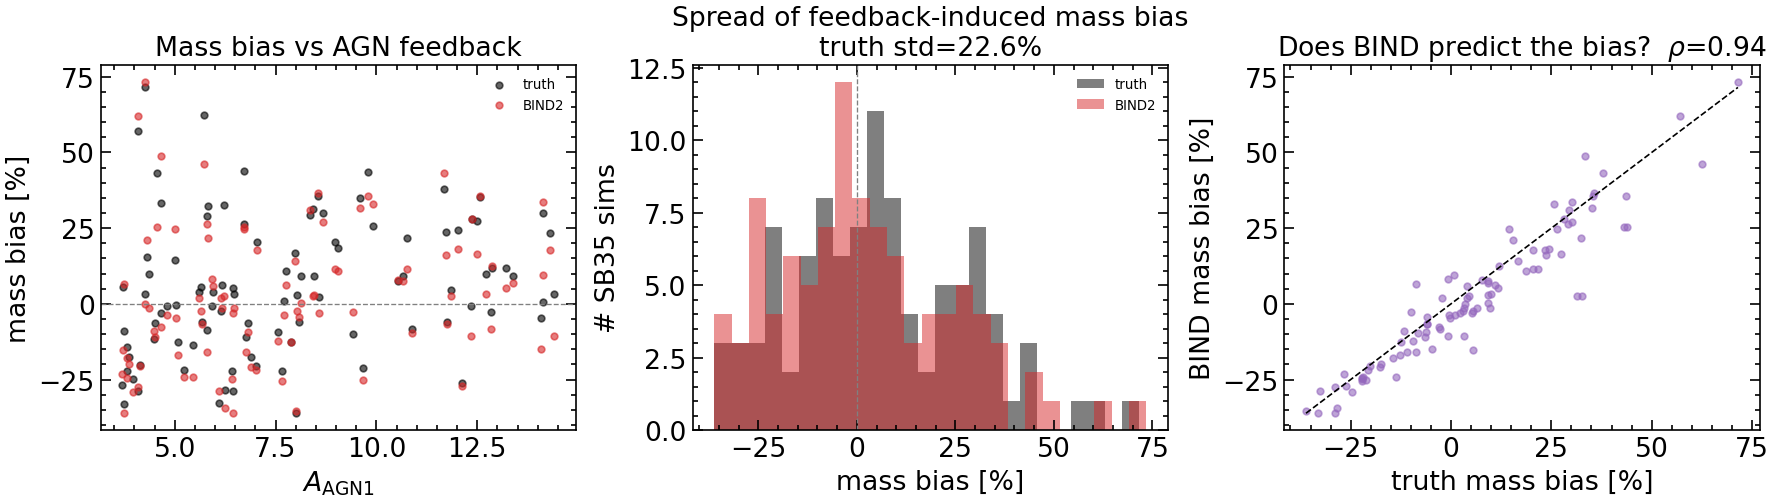

In [7]:
def mass_bias_table(which):
    slope_cv, norm_cv, _, _ = CV_FIT[which]
    off = per_sim_ym_offsets(sb_tbl, which, slope=slope_cv)
    off['dlogM'] = (off['norm'] - norm_cv) / slope_cv
    off['mass_bias_pct'] = (10 ** off['dlogM'] - 1) * 100
    return off


def fig_y4_mass_bias(save=True):
    bt = mass_bias_table('truth'); bg = mass_bias_table('gen')
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

    # ---- (a) mass bias vs A_AGN1 with linmix_lite fit ----
    ax = axes[0]
    x = bt['p5'].to_numpy(); y = bt['dlogM'].to_numpy()
    f_t = linmix_lite(x, y)
    xg = bg['p5'].to_numpy(); yg = bg['dlogM'].to_numpy()
    f_g = linmix_lite(xg, yg)
    ax.scatter(x, y, s=18, c='k', alpha=0.6, label='truth')
    ax.scatter(xg, yg, s=18, c='tab:red', alpha=0.6, label='BIND2')
    xs = np.linspace(np.nanmin(x), np.nanmax(x), 30)
    ax.plot(xs, f_t['slope'] * xs + f_t['intercept'], 'k-', lw=1.8,
            label=(f'truth: $\\Delta\\log M = ({f_t["slope"]:+.3f}) A_{{AGN1}} + '
                   f'({f_t["intercept"]:+.3f})\n'
                   f'$\\sigma_{{int}}$={fmt_ci(f_t["sigma_int"], f_t["sigma_int_lo"], f_t["sigma_int_hi"])}'))
    ax.plot(xs, f_g['slope'] * xs + f_g['intercept'], color='tab:red', lw=1.8, ls='--',
            label=f'BIND : slope={fmt_ci(f_g["slope"], f_g["slope_lo"], f_g["slope_hi"])}')
    ax.axhline(0, color='0.5', lw=0.6, ls=':')
    ax.set_xlabel(PARAM_LABELS[5]); ax.set_ylabel(r'mass bias $\Delta\log M$ [dex]')
    ax.set_title('Money plot: mass bias vs AGN-1'); ax.legend(fontsize=7, loc='best')

    # ---- (b) distribution of induced mass bias across SB35 + literature bands ----
    ax = axes[1]
    bins = np.linspace(min(bt['dlogM'].min(), bg['dlogM'].min()) - 0.02,
                       max(bt['dlogM'].max(), bg['dlogM'].max()) + 0.02, 28)
    ax.hist(bt['dlogM'], bins=bins, color='k', alpha=0.5, label='truth')
    ax.hist(bg['dlogM'], bins=bins, color='tab:red', alpha=0.5, label='BIND2')
    ax.axvline(0, color='0.5', lw=0.6, ls=':')
    # literature (1-b) overlays — convert (1-b) into a notional dlogM offset relative to 1
    # using log10(1-b). These are absolute mass-bias references, drawn at their location.
    for name, e in MASS_BIAS_LIT.items():
        dlm = np.log10(e['value'])
        dlm_err = e['err'] / (e['value'] * np.log(10))
        ax.axvspan(dlm - dlm_err, dlm + dlm_err, alpha=0.15,
                   color={'Planck SZ (2015)': 'tab:blue',
                          'Weighing the Giants (WtG)': 'tab:green',
                          'CCCP (Hoekstra+15)': 'tab:orange'}[name],
                   label=f'{name}: $(1-b)$={e["value"]:.2f}±{e["err"]:.2f}')
    s_t, sl, sh = bootstrap_ci(bt['dlogM'].to_numpy(), np.nanstd)
    ax.set_xlabel(r'$\Delta\log M$ [dex]'); ax.set_ylabel('# SB35 sims')
    ax.set_title(f'SB35 feedback range vs literature $(1-b)$ band\n'
                 f'SB35 std (truth) = {fmt_ci(s_t, sl, sh)} dex',
                 fontsize=9)
    ax.legend(fontsize=6, loc='upper left')

    # ---- (c) BIND vs truth predicted bias (per sim) ----
    ax = axes[2]
    mrg = bt[['sim_id', 'dlogM']].merge(bg[['sim_id', 'dlogM']], on='sim_id', suffixes=('_t', '_g'))
    ax.scatter(mrg['dlogM_t'], mrg['dlogM_g'], s=18, c='tab:purple', alpha=0.6)
    lim = [mrg['dlogM_t'].min(), mrg['dlogM_t'].max()]
    ax.plot(lim, lim, 'k--', lw=1)
    rho, lo, hi = spearman_boot(mrg['dlogM_t'].to_numpy(), mrg['dlogM_g'].to_numpy())
    ax.set_xlabel(r'truth $\Delta\log M$ [dex]'); ax.set_ylabel(r'BIND $\Delta\log M$ [dex]')
    ax.set_title(f'Does BIND predict the bias?  $\\rho$={fmt_ci(rho, lo, hi, ".2f")}')
    fig.tight_layout()
    if save:
        save_fig(fig, 'figY4_mass_bias_money')

    sb35_range_dex = (bt['dlogM'].min(), bt['dlogM'].max())
    sb35_range_1mb = (10 ** sb35_range_dex[0], 10 ** sb35_range_dex[1])
    out = {
        'truth_dAGN1_slope':       f_t['slope'],
        'truth_dAGN1_slope_lo':    f_t['slope_lo'],
        'truth_dAGN1_slope_hi':    f_t['slope_hi'],
        'truth_dAGN1_sigma_int':   f_t['sigma_int'],
        'gen_dAGN1_slope':         f_g['slope'],
        'gen_dAGN1_slope_lo':      f_g['slope_lo'],
        'gen_dAGN1_slope_hi':      f_g['slope_hi'],
        'truth_dlogM_std':         s_t,
        'sb35_dlogM_range':        sb35_range_dex,
        'sb35_1mb_range':          sb35_range_1mb,
        'bind_vs_truth_spearman':  (rho, lo, hi),
    }
    print('=' * 70)
    print(f'SB35 feedback-induced mass bias range (truth) : {sb35_range_dex[0]:+.3f} .. {sb35_range_dex[1]:+.3f} dex')
    print(f'  i.e. inferred (1-b) ranges                  : {sb35_range_1mb[0]:.2f} .. {sb35_range_1mb[1]:.2f}')
    print(f'Truth slope d(logM)/d(A_AGN1)                 : {fmt_ci(f_t["slope"], f_t["slope_lo"], f_t["slope_hi"])} dex')
    print(f'BIND  slope d(logM)/d(A_AGN1)                 : {fmt_ci(f_g["slope"], f_g["slope_lo"], f_g["slope_hi"])} dex')
    print(f'BIND-truth per-sim bias Spearman              : {fmt_ci(rho, lo, hi, ".2f")}')
    print('\nLiterature (1-b) comparison:')
    for name, e in MASS_BIAS_LIT.items():
        in_range = sb35_range_1mb[0] <= e['value'] <= sb35_range_1mb[1]
        marker = 'inside' if in_range else 'OUTSIDE'
        print(f'  {name:30s} (1-b)={e["value"]:.2f}±{e["err"]:.2f}  [{marker} SB35 range]')
    return fig, out


fig, MASS_BIAS = fig_y4_mass_bias()
plt.show()


## 6. Figure Y5 — Clean 1P sequences

The 1P suite varies one parameter at a time, so the $Y$–$M$ normalization offset
traces a clean monotonic response to each feedback knob — the cleanest view of
how a single feedback process moves the SZ scaling relation. Truth vs BIND.

  wrote tsz_ym_mass_bias_figs/figY5_1p_sequences.pdf
  wrote tsz_ym_mass_bias_figs/figY5_1p_sequences.png


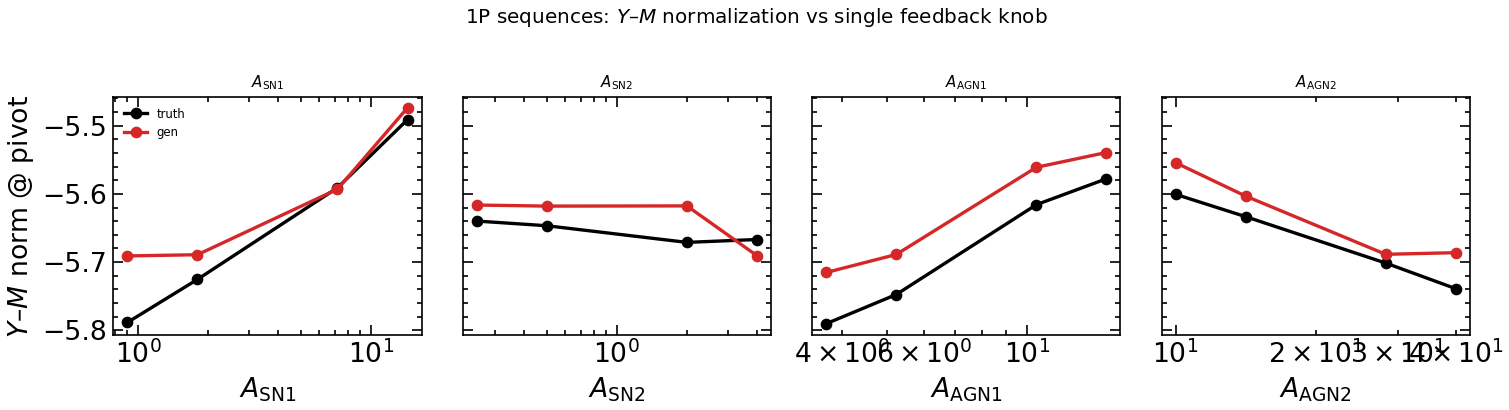

In [8]:
def fig_y5_1p_sequences(params=None, save=True):
    """1P parameter sweeps in (Y at pivot) and median per-halo offset
    with bootstrap 68% CI shaded envelope from the per-halo population."""
    if params is None:
        params = FEEDBACK_PARAMS
    fig, axes = plt.subplots(2, len(params), figsize=(3.4 * len(params), 6),
                             sharex='col')
    slope_cv = CV_FIT['truth'][0]
    for c, j in enumerate(params):
        # Y at pivot per sim using a fixed-slope normalization
        off_t = per_sim_ym_offsets(oneP_tbl, 'truth', slope=slope_cv)
        off_g = per_sim_ym_offsets(oneP_tbl, 'gen',   slope=slope_cv)
        for ax, off, col, lbl in ((axes[0, c], off_t, 'k', 'truth'),
                                  (axes[0, c], off_g, 'tab:red', 'BIND2')):
            grp = off.groupby(f'p{j}')['norm'].agg(['mean', 'std', 'count']).sort_index()
            ax.errorbar(grp.index.to_numpy(), grp['mean'].to_numpy(),
                        yerr=(grp['std'] / np.sqrt(np.maximum(grp['count'], 1))).to_numpy(),
                        fmt='o-', color=col, ms=4, lw=1.2,
                        label=lbl if c == 0 else None)
        axes[0, c].set_xlabel(PARAM_LABELS[j])
        if c == 0:
            axes[0, c].set_ylabel(r'$\log Y$ at pivot [dex]'); axes[0, c].legend(fontsize=7)
        axes[0, c].set_title(f'1P sequence — {PARAM_LABELS[j]}', fontsize=9)

        # bottom row: per-halo logY_g - logY_t across the sequence
        rows = []
        for pv, sub in oneP_tbl.groupby(f'p{j}'):
            d = _logY(sub, 'gen') - _logY(sub, 'truth')
            d = d[np.isfinite(d)]
            if d.size < 5:
                continue
            med, lo, hi = bootstrap_ci(d, np.nanmedian)
            rows.append((pv, med, lo, hi, d.size))
        rows = np.array(rows)
        if rows.size:
            ax = axes[1, c]
            ax.errorbar(rows[:, 0], rows[:, 1],
                        yerr=[rows[:, 1] - rows[:, 2], rows[:, 3] - rows[:, 1]],
                        fmt='s-', color='tab:purple', ms=4, lw=1.2)
            ax.axhline(0, color='0.5', lw=0.6, ls=':')
            ax.set_xlabel(PARAM_LABELS[j])
            if c == 0:
                ax.set_ylabel(r'BIND − truth $\log Y$ [dex]')
    fig.suptitle('1P clean sequences — top: $Y$ normalization; bottom: BIND − truth offset (68% CI)',
                 y=1.00, fontsize=10)
    fig.tight_layout()
    if save:
        save_fig(fig, 'figY5_1p_sequences')
    return fig


fig = fig_y5_1p_sequences()
plt.show()


## 7. Scorecard

In [9]:
def ym_scorecard():
    print('=' * 78)
    print('Y–M / mass-bias scorecard (bootstrap 68% CI)')
    print('=' * 78)

    # [1] Y–M per suite (linmix_lite)
    print('\n[1] Y–M slope, intercept, intrinsic scatter (per suite)')
    for (w, s), f in Y1_FITS.items():
        print(f'    {s:4s} / {w:5s}  slope = {fmt_ci(f["slope"], f["slope_lo"], f["slope_hi"])}'
              f'  intercept = {fmt_ci(f["intercept"], f["intercept_lo"], f["intercept_hi"])}'
              f'  sigma_int = {fmt_ci(f["sigma_int"], f["sigma_int_lo"], f["sigma_int_hi"])}')

    # [2] Feedback-driven scatter decomposition
    sig_cv = CV_NULL.get('sigma_cv', float('nan'))
    print(f'\n[2] CV null scatter floor (truth)         : {sig_cv:.3f} dex')
    print(f'    BIND emulator floor on CV (sigma_emu) : {CV_NULL.get("sigma_emu_cv", float("nan")):.3f} dex'
          f'  (bias {CV_NULL.get("bias_emu_cv", float("nan")):+.3f})')
    for s in ('CV', 'SB35'):
        f = Y1_FITS[('truth', s)]
        sig_fb, frac = decompose_scatter(f['sigma_int'], sig_cv)
        print(f'    {s:4s} truth: sigma_int={f["sigma_int"]:.3f} dex  ->  '
              f'sigma_fb={sig_fb:.3f} dex ({100*(1-frac):.0f}% of variance is feedback)')

    # [3] Mass bias range and BIND-truth fidelity
    print('\n[3] Mass bias across SB35 feedback range (truth):')
    rng = MASS_BIAS['sb35_dlogM_range']; rng1mb = MASS_BIAS['sb35_1mb_range']
    print(f'    Δlog M ∈ [{rng[0]:+.3f}, {rng[1]:+.3f}] dex')
    print(f'    (1-b)  ∈ [{rng1mb[0]:.2f}, {rng1mb[1]:.2f}]')
    print(f'    σ(Δlog M)    = {MASS_BIAS["truth_dlogM_std"]:.3f} dex')
    print(f'    truth d(Δlog M)/d(A_AGN1) = {fmt_ci(MASS_BIAS["truth_dAGN1_slope"], MASS_BIAS["truth_dAGN1_slope_lo"], MASS_BIAS["truth_dAGN1_slope_hi"])} dex/unit')
    print(f'    BIND  d(Δlog M)/d(A_AGN1) = {fmt_ci(MASS_BIAS["gen_dAGN1_slope"],   MASS_BIAS["gen_dAGN1_slope_lo"],   MASS_BIAS["gen_dAGN1_slope_hi"])}   dex/unit')
    rho, lo, hi = MASS_BIAS['bind_vs_truth_spearman']
    print(f'    BIND-truth per-sim bias Spearman ρ = {fmt_ci(rho, lo, hi, ".2f")}')

    # [4] Literature comparison
    print('\n[4] Literature comparison')
    print('    Y–M slope:')
    slope_sb_t = Y1_FITS[('truth', 'SB35')]
    for name, e in YM_LIT.items():
        sigma = abs(slope_sb_t['slope'] - e['slope']) / max(0.5 * (slope_sb_t['slope_hi'] - slope_sb_t['slope_lo']), 1e-3)
        print(f'      {name:22s}: lit={e["slope"]:.2f}  vs  SB35 truth={slope_sb_t["slope"]:.2f}  (Δ/σ ≈ {sigma:.1f})')
    print('    Mass bias (1-b):')
    for name, e in MASS_BIAS_LIT.items():
        in_range = rng1mb[0] <= e['value'] <= rng1mb[1]
        marker = 'WITHIN SB35 reach' if in_range else 'OUTSIDE SB35 reach'
        print(f'      {name:30s}: (1-b)={e["value"]:.2f}±{e["err"]:.2f}   [{marker}]')

    # [5] Y2 top feedback driver
    print('\n[5] Top norm driver (SB35 truth):')
    r_pt, r_lo, r_hi = Y2_RHOS['truth']
    order = np.argsort(-np.abs(r_pt))
    for k in order[:3]:
        j = k + 1
        print(f'    p{j:2d} {PARAM_LABELS[j]:14s} ρ = {fmt_ci(r_pt[k], r_lo[k], r_hi[k], ".2f")}')

    print('=' * 78)


ym_scorecard()


Y-M relation & feedback-induced mass bias

[CV]
  truth: slope=1.935  norm@14.0=-5.643  scatter=0.190 dex  n=1111
  gen  : slope=1.885  norm@14.0=-5.634  scatter=0.208 dex  n=1111

[SB35]
  truth: slope=1.774  norm@14.0=-5.775  scatter=0.219 dex  n=4272
  gen  : slope=1.769  norm@14.0=-5.763  scatter=0.229 dex  n=4272

Mass bias across SB35 (CV-calibrated Y-M):
  truth: std=22.6%  range=[-36.1, 71.5]%
  BIND : std=22.4%  range=[-36.2, 73.4]%
  BIND-vs-truth bias Spearman: 0.94
